# Problema do Sítio (Goldbarg & Luna)

**Aluno**: Matheus Sousa Marinho <br> 
**Matrícula**: 202206132

**Enunciado:** Um sitiante dispõe de **200 000 m²** de área cultivável. A produção total não pode exceder **60 t** (60 000 kg) por limite de armazenamento. Há áreas mínimas por cultura: **400 m²** de trigo, **800 m²** de arroz e **10 000 m²** de milho. Produtividades (kg/m²): trigo **0,2**, arroz **0,3**, milho **0,4**. Lucros ($/kg): trigo **10,8**, arroz **4,2**, milho **2,03** centavos.

**Pergunta:** como alocar a área entre as culturas para maximizar o lucro total respeitando as restrições?

## Configurando o ambiente

Alinhado ao padrão utilizado em exercícios anteriores: `amplpy` + módulo `open` (solver CBC).

In [1]:
# 1. Instalação
%pip install -U -q amplpy
import sys, subprocess

subprocess.check_call([sys.executable, "-m", "amplpy.modules", "install", "--upgrade", "open"])

Note: you may need to restart the kernel to use updated packages.
$ /home/m9t/Documents/ufg/o-research/.venv/bin/python -m pip install -i https://pypi.ampl.com ampl_module_base ampl_module_open --upgrade
Looking in indexes: https://pypi.ampl.com
Imported ampl_module_base.
Imported ampl_module_base.
Imported ampl_module_open.


0

In [2]:
# 2. PATH do AMPL e importação
import os, sys, subprocess

caminho_mod = subprocess.check_output([sys.executable, "-m", "amplpy.modules", "path"]).decode().strip()
os.environ["PATH"] += os.pathsep + caminho_mod

from amplpy import AMPL

print("AMPL pronto (solver padrão configurado por modelo abaixo).")

AMPL pronto (solver padrão configurado por modelo abaixo).


## Parte I — Duas abordagens para as variáveis de decisão

### 1. Modelo com **área plantada** (m²): $X_T$, $X_A$, $X_M$

Coeficientes da função objetivo em centavos por m²: $2{,}16$, $1{,}26$, $0{,}812$.

In [4]:
def modelo1():
    """Modelo em áreas (m²), conforme Goldbarg AMPL. Retorna instância AMPL resolvida."""
    ampl = AMPL()
    ampl.eval("option solver cbc;")
    ampl.eval(
        """
        param ProdTrigo := 0.2;
        param ProdArroz := 0.3;
        param ProdMilho := 0.4;

        var XT >= 0;
        var XA >= 0;
        var XM >= 0;

        maximize z: 2.16*XT + 1.26*XA + 0.812*XM;

        subject to
        c1: XT >= 400;
        c2: XA >= 800;
        c3: XM >= 10000;
        c4: XT + XA + XM <= 200000;
        c5: 0.2*XT + 0.3*XA + 0.4*XM <= 60000;
        """
    )
    ampl.solve()
    ampl.eval("display XT, XA, XM;")
    ampl.eval('display "Produção em kg:";')
    ampl.eval('display "kg_Trigo =", ProdTrigo * XT;')
    ampl.eval('display "kg_Arroz =", ProdArroz * XA;')
    ampl.eval('display "kg_Milho =", ProdMilho * XM;')
    return ampl


ampl_area = modelo1()

cbc 2.10.12:cbc 2.10.12: optimal solution; objective 417800
0 simplex iterations
XT = 189200
XA = 800
XM = 10000

'Produção em kg:' = 'Produção em kg:'

'kg_Trigo =' = 'kg_Trigo ='
ProdTrigo*XT = 37840

'kg_Arroz =' = 'kg_Arroz ='
ProdArroz*XA = 240

'kg_Milho =' = 'kg_Milho ='
ProdMilho*XM = 4000



### 2. Modelo com **quantidade produzida** (kg): $Q_T$, $Q_A$, $Q_M$

Mesmo problema; variáveis em kg e restrição de área obtida dividindo pela produtividade (como no PDF).

In [8]:
def modelo2():
    """Modelo em quantidades (kg), conforme Goldbarg AMPL."""
    ampl = AMPL()
    ampl.eval("option solver cbc;")
    ampl.eval(
        """
        var QT >= 0;
        var QA >= 0;
        var QM >= 0;

        maximize z: (2.16/0.2)*QT + (1.26/0.3)*QA + (0.812/0.4)*QM;

        subject to
        c1: QT >= 80;
        c2: QA >= 240;
        c3: QM >= 4000;
        c4: (QT/0.2) + (QA/0.3) + (QM/0.4) <= 200000;
        c5: QT + QA + QM <= 60000;
        """
    )
    ampl.solve()
    ampl.eval("display _varname, _var;")
    return ampl


ampl_kg = modelo2()

cbc 2.10.12:cbc 2.10.12: optimal solution; objective 417800
0 simplex iterations
: _varname   _var     :=
1   QT       37840
2   QA         240
3   QM        4000
;



## Parte II — Por que encapsular em funções?

- **Escopo:** cada chamada usa um objeto `AMPL()` próprio; evita sobrescrever variáveis de um modelo ao definir o outro.
- **Reuso:** é fácil rodar de novo com parâmetros alterados (no futuro, pode-se passar dados por `ampl.setOption` / parâmetros AMPL ou gerar strings).
- **Organização:** o notebook fica legível e alinhado ao exemplo `modelo1()` do material em PDF.

De fato, o encapsulamento é uma prática já conhecida que facilita tanto a organização de um código quanto sua escalabilidade também. De fato auxilia tanto no reuso como na manutenção do mesmo.

## Parte III — Equivalência e visualizações

Apesar de encontrarmos equivalências nos modelos, vamos utilizar o matplotlib para visualizar as soluções.

In [6]:
%pip install -q matplotlib pandas

import matplotlib.pyplot as plt
import pandas as pd

z1 = ampl_area.getObjective("z").value()
XT = ampl_area.getVariable("XT").value()
XA = ampl_area.getVariable("XA").value()
XM = ampl_area.getVariable("XM").value()

z2 = ampl_kg.getObjective("z").value()
QT = ampl_kg.getVariable("QT").value()
QA = ampl_kg.getVariable("QA").value()
QM = ampl_kg.getVariable("QM").value()

prod_t, prod_a, prod_m = 0.2, 0.3, 0.4
QT_from_area = prod_t * XT
QA_from_area = prod_a * XA
QM_from_area = prod_m * XM

print(f"Lucro ótimo (modelo m²): z = {z1}")
print(f"Lucro ótimo (modelo kg): z = {z2}")
print(f"Diferença |z1 - z2| = {abs(z1 - z2)}")

tol = 1e-3
assert abs(z1 - z2) < tol, "Objetivos deveriam coincidir"
assert abs(QT - QT_from_area) < tol
assert abs(QA - QA_from_area) < tol
assert abs(QM - QM_from_area) < tol
print("Consistência m² → kg verificada.")

df = pd.DataFrame(
    {
        "Área (m²)": [XT, XA, XM],
        "Produção (kg)": [QT, QA, QM],
    },
    index=["Trigo", "Arroz", "Milho"],
)
df

Note: you may need to restart the kernel to use updated packages.
Lucro ótimo (modelo m²): z = 417800.0
Lucro ótimo (modelo kg): z = 417800.0
Diferença |z1 - z2| = 0.0
Consistência m² → kg verificada.


,Área (m²),Produção (kg)
Trigo,189200.0,37840.0
Arroz,800.0,240.0
Milho,10000.0,4000.0


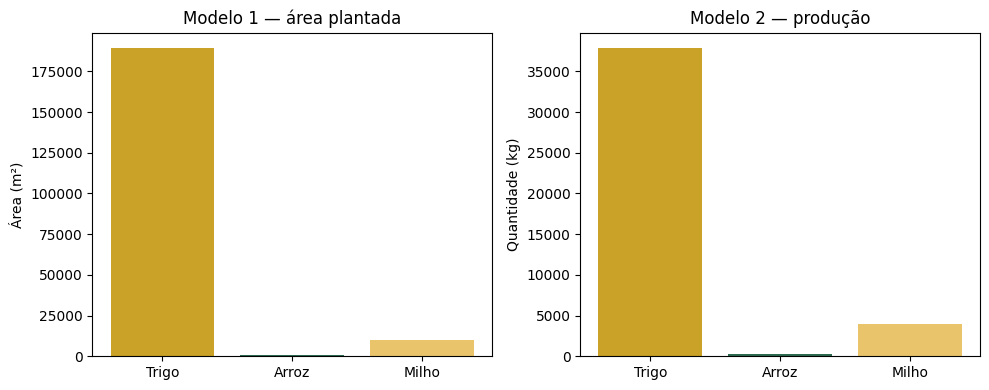

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

culturas = ["Trigo", "Arroz", "Milho"]
axes[0].bar(culturas, [XT, XA, XM], color=["#c9a227", "#2d6a4f", "#e9c46a"])
axes[0].set_ylabel("Área (m²)")
axes[0].set_title("Modelo 1 — área plantada")

axes[1].bar(culturas, [QT, QA, QM], color=["#c9a227", "#2d6a4f", "#e9c46a"])
axes[1].set_ylabel("Quantidade (kg)")
axes[1].set_title("Modelo 2 — produção")

plt.tight_layout()
plt.show()

### Interpretação

#### 1. O lucro total é idêntico nos dois modelos?

**R:** Sim. Os dois modelos são o **mesmo** problema, apenas com outra escolha de variáveis de decisão e consequentemente restrições, logo o valor ótimo de `z` é o mesmo.

Lucro ótimo (modelo m²)  `z = 417800.0` 
Lucro ótimo (modelo kg) `z = 417800.0` 

#### 2. Ao converter a solução do modelo 1 para kg, os valores batem com o modelo 2?

**R:** Sim. As quantidades obtidas com produtividade × área coincidem com `QT`, `QA`, `QM` do segundo modelo.
#### 3. Quais restrições estão **ativas** na solução (área total, armazenamento, mínimos)?

As restrições ativas são:
- **`c4`** (área total): `XT + XA + XM <= 200000`
- **`c5`** (armazenamento, em kg): `0.2*XT + 0.3*XA + 0.4*XM <= 60000`


#### 4. Por que quase toda a área vai para o trigo? Por que arroz e milho ficam nos mínimos?

**R:** Porque o trigo tem o maior **lucro por m²** entre as três culturas. Não é a maior produtividade em kg/m², o que importa para maximizar `z` em função da área é a **rentabilidade por m²**. Com `c4` e `c5` restringindo, convém concentrar área na cultura mais rentável por m² e usar só o mínimo obrigatório nas outras.

#### 5. O que mudaria se a capacidade de armazenamento aumentasse?

**R:** A restrição de armazenamento (`c5`) **relaxa**. A solução ótima pode mudar até outra restrição voltar a ser o gargalo — em extremo, `c5` pode deixar de ser o limitador principal.

---

**Questões para pensar (roteiro)**

**Se o preço do milho subisse muito, como mudaria a solução?**

 A solução ótima seria alterada, modificando as restrições. 

**Se houvesse mão de obra diferenciada por cultura, qual formulação (m² vs. kg) seria mais natural?**

 A solução por kg seria mais natural, pois a mão de obra seria um fator limitante e a demanda em kg seria uma variável de decisão.

**Venda influenciada pela área plantada vs. demanda em kg: quando cada modelo é mais útil?**

 O modelo em área é mais útil quando a venda é influenciada pela área plantada, pois a área plantada é uma variável de decisão do modelo. Já o modelo em quantidade é mais útil quando a venda é influenciada pela demanda em kg, pois a demanda em kg é uma variável de decisão do modelo.

### Comparativo das abordagens:

 Basicamente, dependendo da abordagem a modelagem pode ser mais complexa ou não. De certa maneira, se você optar por modelar a área, as demandas em kg deveriam ser tratadas como parâmetros dependentes de área, sendo uma variável produtividade x área, por exemplo. Na segunda modelagem, a área total acabou se transformando em uma restrição, tendo quantidade sendo dividida pela produtividade e não um produto.



---

**Referências:** Goldbarg & Luna (2006); [AMPL](https://ampl.com); [HiGHS](https://highs.dev) / CBC via `amplpy` open module.